<a href="https://colab.research.google.com/github/Chinji/chinji.github.io/blob/main/Waithera_Introduction_to_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multinational Human Resource Management Employee Promotion Prediction

# Understanding the context

## Background information

HR analytics is revolutionising the way human resources departments operate, leading
to higher efficiency and better results overall. Human resources have been using
analytics for years. However, the collection, processing, and analysis of data have been
largely manual, and given the nature of human resources dynamics and HR KPIs, the
approach has been constraining HR. Therefore, it is surprising that HR departments
woke up to the utility of machine learning so late in the game.


## Problem Statement

 Your client is a large Multinational Corporation, and they have nine broad verticals across the organization. One of the problems your client faces is identifying the right people for promotion (only for the manager position and below) and preparing them in time.

Currently, the process they are following is:

* They first identify a set of employees based on recommendations/ past performance.
* Selected employees go through the separate training and evaluation program for each vertical.
* These programs are based on the required skill of each vertical. At the end of the program, based on various factors such as training performance, KPI completion (only employees with KPIs completed greater than 60% are considered) etc., the employee gets a promotion.


For the process mentioned above, the final promotions are only announced after the evaluation, and this leads to a delay in transition to their new roles. Hence, the company needs your help in identifying the eligible candidates at a particular checkpoint so that they can expedite the entire promotion cycle.

They have provided multiple attributes around employees’ past and current performance along with demographics

## Metric of success

The goal is to anticipate whether or not a potential promotee will be promoted after the review process. Finding a model with an accuracy score of at least 80% that can predict whether a potential employee will be promoted or not following the evaluation process is the criterion of success.

# Data analysis and exploration

## Importing the libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression # Logistic Regression Classifier
from sklearn.tree import DecisionTreeClassifier     # Decision Tree Classifier
from sklearn.svm import SVC                         # SVM Classifier
from sklearn.naive_bayes import GaussianNB          # Naive Bayes Classifier
from sklearn.neighbors import KNeighborsClassifier  # KNN Classifier
from sklearn.ensemble import RandomForestClassifier # Random Forest Classifier
from sklearn.svm import SVC 

## Loading the dataset

In [2]:
df = pd.read_csv('https://bit.ly/2ODZvLCHRDataset')
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [3]:
# Exploring the data
print(df.shape)
print(df.dtypes)


(54808, 14)
employee_id               int64
department               object
region                   object
education                object
gender                   object
recruitment_channel      object
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPIs_met >80%             int64
awards_won?               int64
avg_training_score        int64
is_promoted               int64
dtype: object


In [4]:
# Checking for null values
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [5]:
# Checking the number of promoted employees
df["is_promoted"].value_counts()

0    50140
1     4668
Name: is_promoted, dtype: int64

The number of those promoted is less than the number of those not promoted

In [6]:
# Checking the number of employees in each department
df["department"].value_counts()

Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: department, dtype: int64

Sales and marketing department has the most number of employees while R&D has the least number of employees.

In [7]:
# Checking for the unique datatypes in the department column
df["department"].value_counts()

Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: department, dtype: int64

The sales and marketing department has the most number of employees with R&D having the least.

In [8]:
# Investigating the performance of the departments
df.groupby("department")["previous_year_rating"].mean()

department
Analytics            3.557307
Finance              3.506436
HR                   3.482965
Legal                3.405281
Operations           3.632156
Procurement          3.298852
R&D                  3.563596
Sales & Marketing    3.067937
Technology           3.158677
Name: previous_year_rating, dtype: float64

Despite the sales and marketing team having the most number of employees,it ranks really low on performance.
The Analytics department has the highest rating and the technology department has the least.

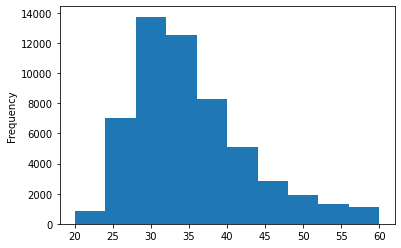

In [9]:
# Checking the age distribution
df['age'].plot.hist()

Majority of the employees are between the ages of 30-35 years old.
Most of the workforce is above 30 years,with the majority ranging from 20-25 years.

# Data Preparation and cleaning

In [10]:
# Re-writing the columns names to lower cas
df.columns = df.columns.str.lower()
# Re-naming the column names for easier interpretation
df.rename(columns = {'kpis_met >80%':'kpis_met_greater_than_80', 'awards_won?':'awards_won'}, inplace = True)

In [11]:
# Filling in the missing values
df['previous_year_rating'].fillna(0,inplace=True)
df['education'].fillna("Other" ,inplace=True)

# Checking the null values again
print(df.isnull().sum()) 

employee_id                 0
department                  0
region                      0
education                   0
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating        0
length_of_service           0
kpis_met_greater_than_80    0
awards_won                  0
avg_training_score          0
is_promoted                 0
dtype: int64


## Encoding the categorical data 

In [12]:
df_encoded =pd.get_dummies(df, columns=['gender','region','education','department','recruitment_channel'], drop_first=True)
df_encoded.columns = df_encoded.columns.str.lower()
df_encoded.head()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,kpis_met_greater_than_80,awards_won,avg_training_score,is_promoted,gender_m,...,department_finance,department_hr,department_legal,department_operations,department_procurement,department_r&d,department_sales & marketing,department_technology,recruitment_channel_referred,recruitment_channel_sourcing
0,65438,1,35,5.0,8,1,0,49,0,0,...,0,0,0,0,0,0,1,0,0,1
1,65141,1,30,5.0,4,0,0,60,0,1,...,0,0,0,1,0,0,0,0,0,0
2,7513,1,34,3.0,7,0,0,50,0,1,...,0,0,0,0,0,0,1,0,0,1
3,2542,2,39,1.0,10,0,0,50,0,1,...,0,0,0,0,0,0,1,0,0,0
4,48945,1,45,3.0,2,0,0,73,0,1,...,0,0,0,0,0,0,0,1,0,0


# Data Modelling

In [13]:
# Set predictors and the target
X = df_encoded.drop(['is_promoted','employee_id'], axis=1)
Y = df_encoded['is_promoted']

In [14]:
# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.3, random_state=0)


In [15]:
#Normalisation
norm = MinMaxScaler().fit(X_train) 
X_train = norm.transform(X_train) 
X_test = norm.transform(X_test)

We are translating data into the range [0, 1] / simply transforming data onto the unit sphere to reduce the complex data structure into its simplest, most stable structure to minimize redundancy.

In [24]:
#Instantiate the classifiers
#Logistic regression produces a single linear decision boundary dividing the 
#feature space into two decision regions
logistic_classifier = LogisticRegression()

#Decision classification divides the feature space into rectangular regions
decision_classifier = DecisionTreeClassifier()


#Support vector machine is highly preferred by many as it produces significant
#accuracy with less computation power
svm_classifier = SVC()

#The KNN algorithm assumes that similar things exist in close proximity. 
#In other words, similar things are near to each other
knn_classifier = KNeighborsClassifier()

#Naive Bayes classifiers are a collection of classification algorithms 
#based on Bayes’ Theorem.It is not a single algorithm but a family of algorithms
# where all of them share a common principle,i.e. every pair of features being
# classified is independent of each other.
naive_classifier = GaussianNB()

#A random forest is a meta estimator that fits a number of decision tree 
#classifiers on various sub-samples of the dataset and uses averaging to \
#improve the predictive accuracy and control over-fitting.
random_forest_classifier = RandomForestClassifier()


In [17]:
#Fitting
max_iter = 60000
logistic_classifier.fit(X_train, Y_train)
decision_classifier.fit(X_train, Y_train)
svm_classifier.fit(X_train, Y_train)
knn_classifier.fit(X_train, Y_train)
naive_classifier.fit(X_train, Y_train)
random_forest_classifier.fit(X_train, Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


RandomForestClassifier()

In [18]:
#Predict results

logistic_y_prediction = logistic_classifier.predict(X_test) 
decision_y_prediction = decision_classifier.predict(X_test) 
svm_y_prediction = svm_classifier.predict(X_test) 
knn_y_prediction = knn_classifier.predict(X_test) 
naive_y_prediction = naive_classifier.predict(X_test) 
random_y_prediction = random_forest_classifier.predict(X_test)


In [19]:
#Print accuracy of classifiers

print(accuracy_score(logistic_y_prediction, Y_test))
print(accuracy_score(decision_y_prediction, Y_test))
print(accuracy_score(svm_y_prediction, Y_test))
print(accuracy_score(knn_y_prediction, Y_test))
print(accuracy_score(naive_y_prediction, Y_test))
print(accuracy_score(random_y_prediction, Y_test))

0.9319467250501733
0.9044578239980539
0.929757343550447
0.9120598430943259
0.3204403089460561
0.9358389588274646


In [20]:
#Print the classification report
print('Logistic classifier:')
print(classification_report(Y_test, logistic_y_prediction))

print('Decision Tree classifier:')
print(classification_report(Y_test, decision_y_prediction))

print('SVM Classifier:')
print(classification_report(Y_test, svm_y_prediction))

print('KNN Classifier:')
print(classification_report(Y_test, knn_y_prediction))

print('Naive Bayes Classifier:')
print(classification_report(Y_test, naive_y_prediction)) 

print('Random Forest Classifier:')
print(classification_report(Y_test, random_y_prediction))

Logistic classifier:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     15057
           1       0.88      0.22      0.36      1386

    accuracy                           0.93     16443
   macro avg       0.91      0.61      0.66     16443
weighted avg       0.93      0.93      0.91     16443

Decision Tree classifier:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     15057
           1       0.44      0.47      0.45      1386

    accuracy                           0.90     16443
   macro avg       0.69      0.71      0.70     16443
weighted avg       0.91      0.90      0.91     16443

SVM Classifier:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     15057
           1       0.99      0.17      0.29      1386

    accuracy                           0.93     16443
   macro avg       0.96      0.58      0.63     16443
weighted av

# Visualising the decision tree clasifier

[Text(0.7474048332527673, 0.99, 'avg_training_score <= 0.858\ngini = 0.156\nsamples = 38365\nvalue = [35083, 3282]'),
 Text(0.4993960508279453, 0.97, 'kpis_met_greater_than_80 <= 0.5\ngini = 0.142\nsamples = 37963\nvalue = [35035, 2928]'),
 Text(0.09371888349452312, 0.95, 'awards_won <= 0.5\ngini = 0.067\nsamples = 24605\nvalue = [23753, 852]'),
 Text(0.06868963869399689, 0.93, 'previous_year_rating <= 0.9\ngini = 0.058\nsamples = 24351\nvalue = [23620, 731]'),
 Text(0.03695369081357781, 0.91, 'avg_training_score <= 0.358\ngini = 0.037\nsamples = 21462\nvalue = [21056, 406]'),
 Text(0.005117439349216203, 0.89, 'avg_training_score <= 0.308\ngini = 0.006\nsamples = 11433\nvalue = [11399, 34]'),
 Text(0.002027664647802647, 0.87, 'avg_training_score <= 0.258\ngini = 0.001\nsamples = 9376\nvalue = [9371, 5]'),
 Text(0.0016414428101259521, 0.85, 'gini = 0.0\nsamples = 8191\nvalue = [8191, 0]'),
 Text(0.0024138864854793413, 0.85, 'department_sales & marketing <= 0.5\ngini = 0.008\nsamples = 1

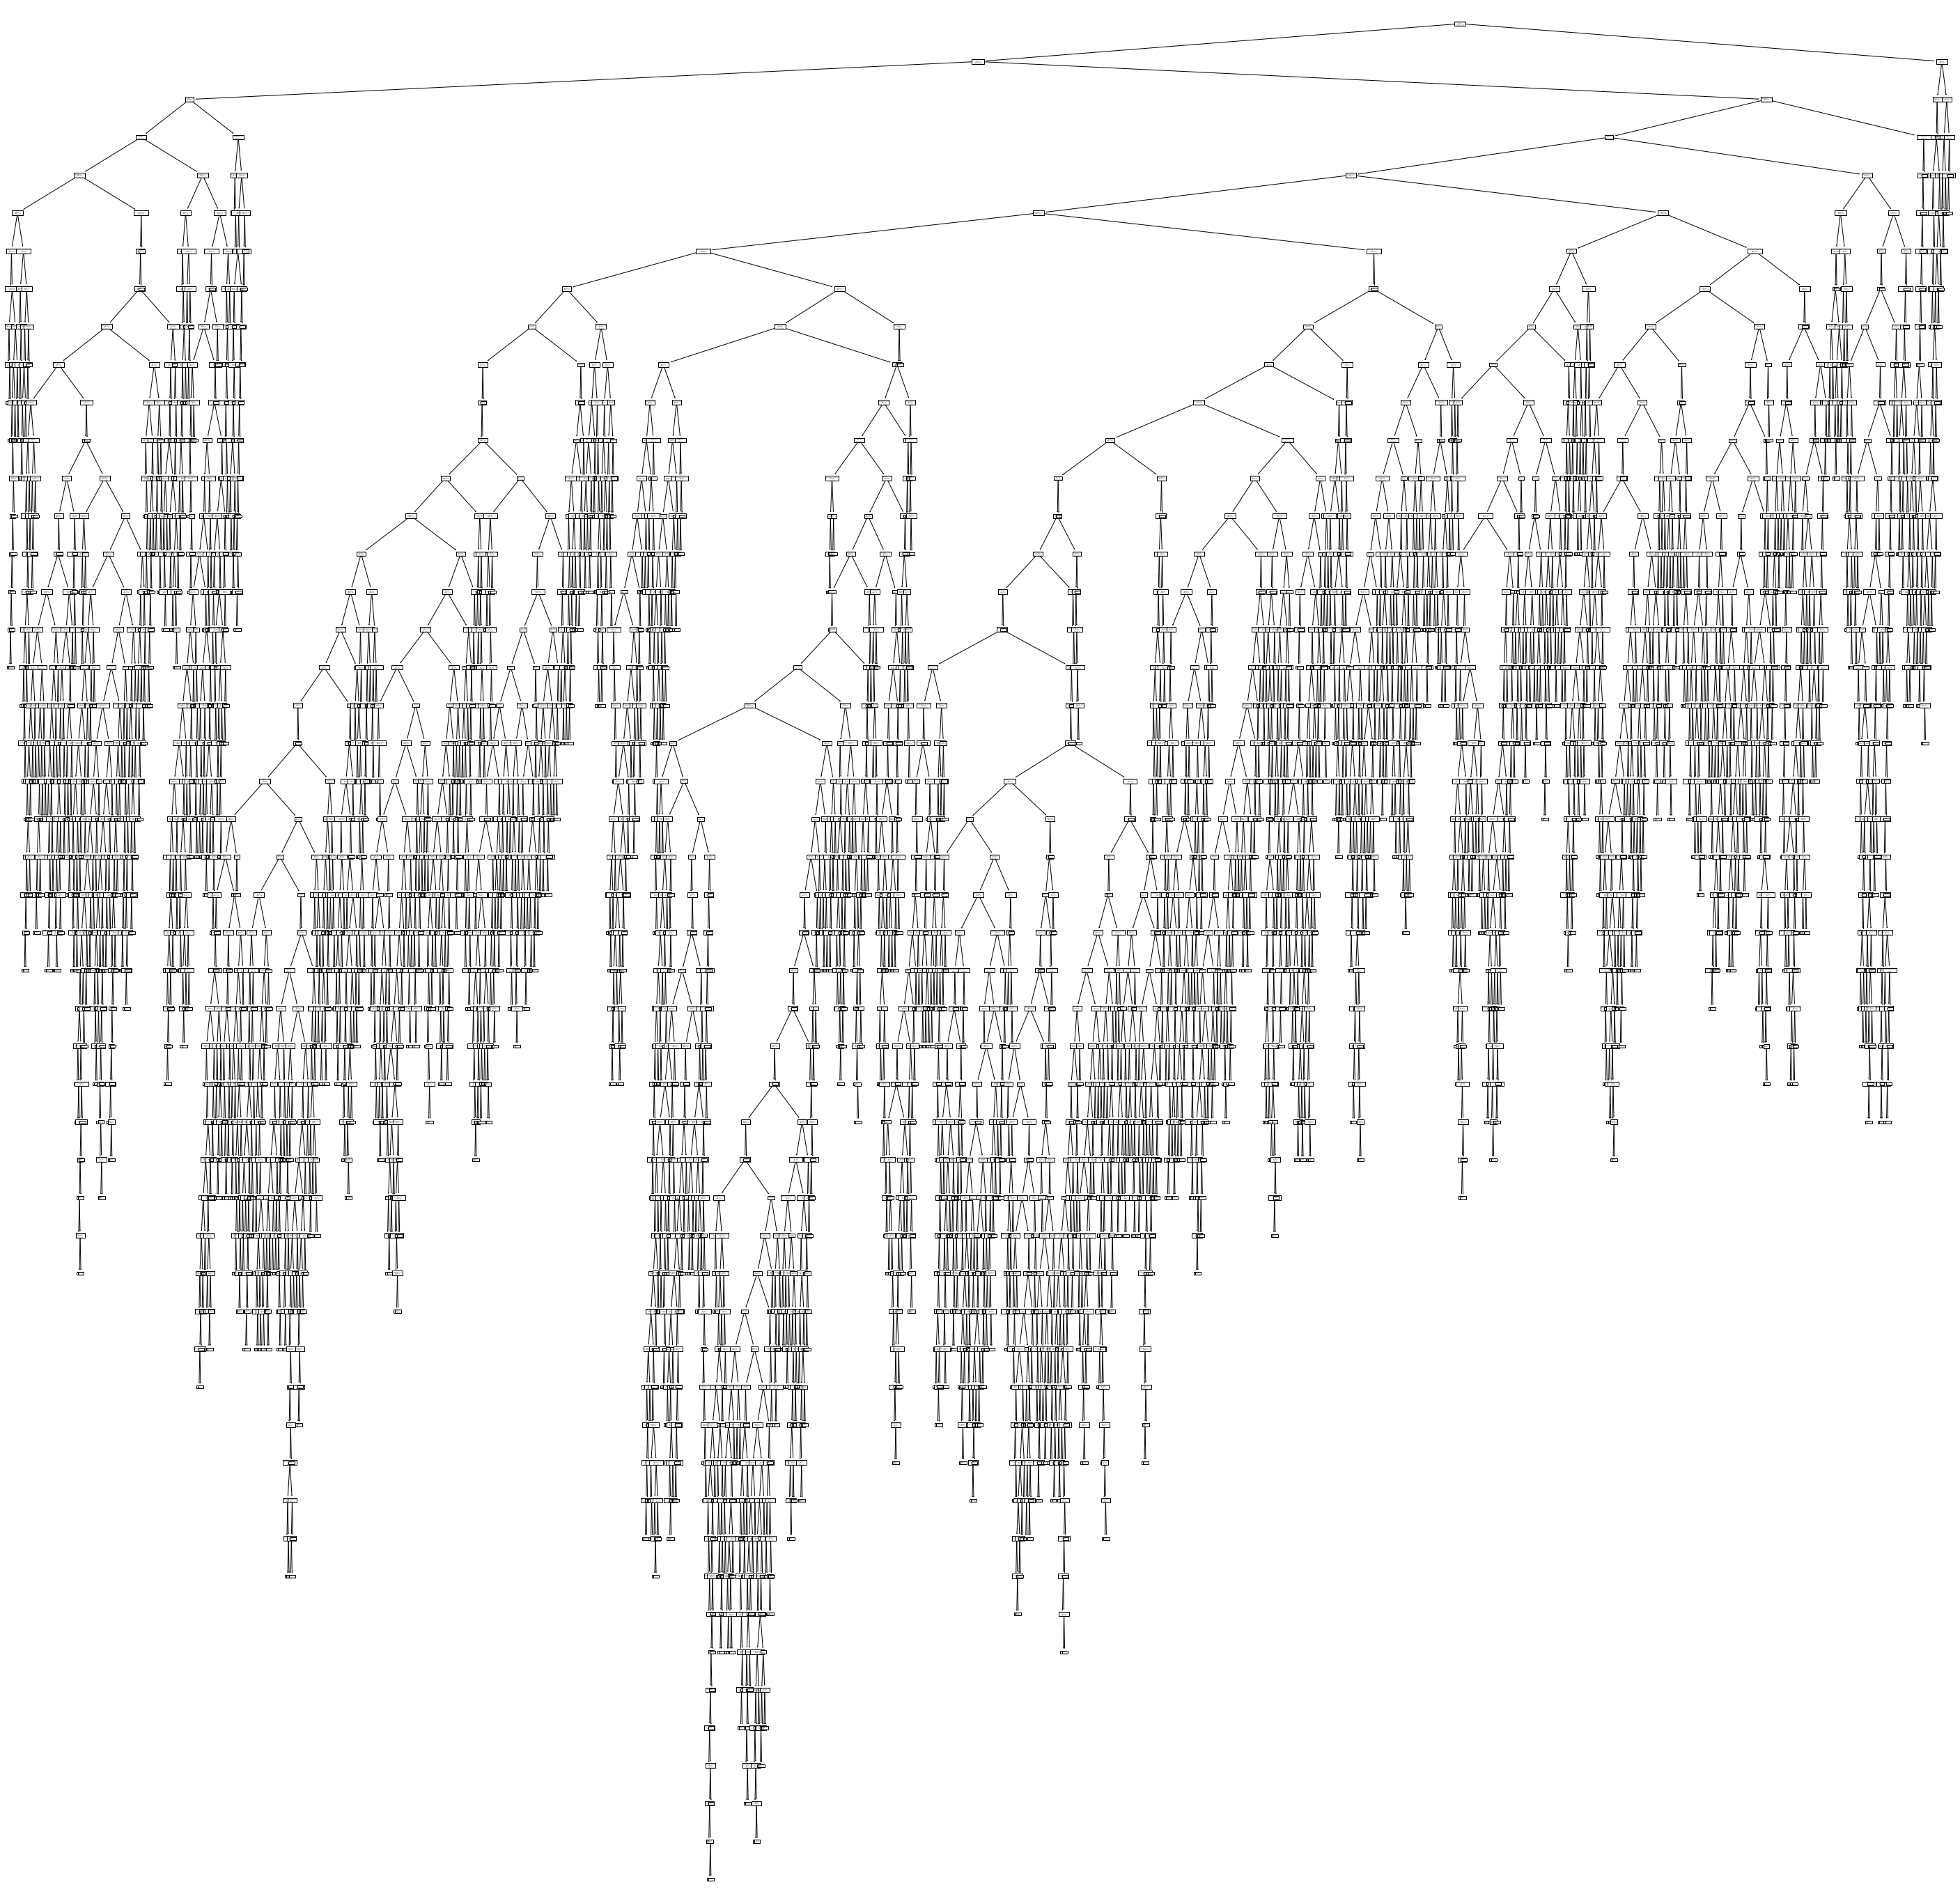

In [23]:
from sklearn import tree
plt.figure(figsize=(50, 50))
tree.plot_tree(decision_classifier, feature_names=X.columns)

# Conclusion and Recommendations


We surpassed the goal of achieving an accuracy score of 80%. Random Forest was the most accurate of the six classifiers, scoring 93 percent accuracy. It is something I would advocate for making decisions about staff promotions.